## Proposed Strategy — LSTM Approach

Adapted from *Deep Learning for Options Trading: An End-To-End Approach* (Tan, Roberts, Zohren, ICAIF 2024).

**Changes from V6 → V7**
| # | Location | Fix |
|---|----------|-----|
| 1 | `compute_loss` | `delta_pos` now uses `σ_{t-1}` for the previous position (Eq. 13) |
| 2 | `compute_loss` | Straddle-only return; SPY component removed |
| 3 | `StraddleLSTM` | Learnable entry threshold `θ` (log-parameterised `nn.Parameter`) |
| 4 | `backtest` | Strike-change detection: forced close+reopen when ATM strike shifts |
| 5 | `backtest` | Option-1 exit: one position at a time; closed at next signal or EOD |

In [ ]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, Optional

### Section 0 — Global Configuration

Change `BAR_MINUTES` to test different bar lengths. Everything else is derived automatically.

In [ ]:
# ── Bar length (change this to test 5, 30, 60 etc.) ──────────────────────
BAR_MINUTES: int = 15

# Derived — do NOT edit
BARS_PER_DAY:   int   = int(6.5 * 60 / BAR_MINUTES)   # 26 for 15-min
ANNUALISATION:  float = math.sqrt(252 * BARS_PER_DAY)  # per-bar → annual

# Feature lookback windows (in bars)
FEAT1_K:    list = [1, 4, 8, 13, 26]      # Feature I  — normalised returns
MACD_SHORT: list = [2, 4, 8]              # Feature II — MACD short scales
MACD_LONG:  list = [8, 16, 32]            # Feature II — MACD long scales
FEAT3_N:    list = [1, 5, 10, 20]         # Feature III — momentum lookbacks

# Network / training
TRAJECTORY_LEN:        int   = 20     # τ — LSTM sequence length (bars)
SIGMA_TGT:             float = 0.15   # annualised vol target (15 %)
VOL_EWM_SPAN:          int   = BARS_PER_DAY  # ≈ 1 trading day for σ_t EWMSD
SIGNAL_THRESHOLD_INIT: float = 0.05   # initial value of learnable entry threshold

# Loss hyper-params
TC_COST_BPS: float = 3.0    # transaction cost (bps) for turnover regularisation
ES_ALPHA:    float = 0.05   # tail fraction for Expected Shortfall penalty
ES_LAMBDA:   float = 0.1    # weight on ES term in combined loss

# Train / test split
TRAIN_DAYS: int = 252

### Section 1 — Data Loading & Bar Resampling

In [ ]:
def load_and_resample(spy_path: str, opt_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load minute-level CSVs and resample to BAR_MINUTES bars.
    SPY : timestamp, open, high, low, close, volume, vwap, transactions
    OPT : timestamp, type[C/P], strike, open, high, low, close, volume, vwap
    """
    spy = pd.read_csv(spy_path, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
    opt = pd.read_csv(opt_path, parse_dates=["timestamp"]).set_index("timestamp").sort_index()

    rule = f"{BAR_MINUTES}min"

    spy_bars = spy.resample(rule, label="left", closed="left").agg(
        open=("open", "first"), high=("high", "max"),
        low=("low", "min"),     close=("close", "last"),
        volume=("volume", "sum"), vwap=("vwap", "mean"),
    ).dropna(subset=["open", "close"])

    opt_bars = (opt.groupby(["type", "strike"])
                   .resample(rule, label="left", closed="left")
                   .agg(open=("open", "first"), close=("close", "last"),
                        volume=("volume", "sum"))
                   .reset_index()
                   .dropna(subset=["open", "close"]))

    # Regular trading hours only
    spy_bars = spy_bars.between_time("09:30", "15:45")
    opt_bars = opt_bars[opt_bars["timestamp"].dt.time.between(
        pd.Timestamp("09:30").time(), pd.Timestamp("15:45").time())]

    return spy_bars, opt_bars

### Section 2 — Straddle Series Construction

For every bar, find the ATM strike with both call and put quoted (moneyness 0.95–1.05).
`strike` is stored in the output DataFrame and propagated to `feat_df` for use in the
backtest's strike-change detection.

In [ ]:
def build_straddle_series(spy_bars: pd.DataFrame,
                          opt_bars: pd.DataFrame) -> pd.DataFrame:
    records = []
    opt_by_ts = opt_bars.set_index("timestamp")

    for ts, spy_row in spy_bars.iterrows():
        spy_close = spy_row["close"]
        spy_open  = spy_row["open"]

        try:
            opt_t = opt_by_ts.loc[ts]
            if isinstance(opt_t, pd.Series):
                opt_t = opt_t.to_frame().T
            else:
                opt_t = opt_t.reset_index()
        except KeyError:
            continue

        has_both = (
            opt_t.groupby("strike")["type"]
                 .apply(lambda s: {"C", "P"}.issubset(set(s)))
        )
        valid_strikes = has_both[has_both].index.tolist()
        if not valid_strikes:
            continue

        # FIX: Select ATM strike using the known open price of the bar,
        # eliminating future leakage.
        atm_strike = min(valid_strikes, key=lambda k: abs(k - spy_open))

        if not (0.95 <= spy_open / atm_strike <= 1.05):
            continue

        call_row = opt_t[(opt_t["type"] == "C") & (opt_t["strike"] == atm_strike)].iloc[0]
        put_row  = opt_t[(opt_t["type"] == "P") & (opt_t["strike"] == atm_strike)].iloc[0]

        if any(pd.isna(v) or v <= 0 for v in [
                call_row["open"], call_row["close"],
                put_row["open"],  put_row["close"]]):
            continue

        market_close = ts.normalize() + pd.Timedelta(hours=15, minutes=59)
        minutes_left = max((market_close - ts).total_seconds() / 60, 1)

        records.append({
            "timestamp":          ts,
            "date":               ts.date(),
            "strike":             atm_strike,
            "call_open":          call_row["open"],
            "call_close":         call_row["close"],
            "put_open":           put_row["open"],
            "put_close":          put_row["close"],
            "straddle_open":      call_row["open"]  + put_row["open"],
            "straddle_close":     call_row["close"] + put_row["close"],
            "log_moneyness_call": math.log(spy_open / atm_strike), # Updated to spy_open
            "log_moneyness_put":  math.log(atm_strike / spy_open), # Updated to spy_open
            "dte_frac":           minutes_left / (252 * 390),
            "spy_close":          spy_close,
            "spy_open":           spy_open,
            "spy_log_ret":        math.log(spy_close / spy_open) if spy_open > 0 else 0.0,
        })

    df = pd.DataFrame(records).set_index("timestamp").sort_index()

    # ── CRITICAL FIX for Dynamic Strikes ─────────────────────────────────────
    # Compute standard close-to-close returns within each day
    cc_ret = df.groupby("date")["straddle_close"].transform(lambda g: np.log(g / g.shift(1)))

    # Compute intrabar close-to-open returns for the new strike
    co_ret = np.log(df["straddle_close"] / df["straddle_open"])

    # Identify intraday strike changes (ignore first bar of day where shift(1) is NaN)
    prev_strike = df.groupby("date")["strike"].shift(1)
    strike_changed = (prev_strike.notna()) & (df["strike"] != prev_strike)

    # Use intrabar return if the strike changed, otherwise use standard return
    df["straddle_log_ret"] = np.where(strike_changed, co_ret, cc_ret)

    return df.dropna(subset=["straddle_log_ret"])

### Section 3 — Feature Engineering

All features at bar *t* use **only** data from bars ≤ t−1 (via `.shift(1)`), guaranteeing no future leakage.

| # | Feature | Paper lookbacks | Our bar lookbacks |
|---|---------|----------------|-------------------|
| I | Normalised returns | 1,5,10,15,20 days | 1,4,8,13,26 bars |
| II | MACD | S∈{2,4,8}, L∈{8,16,32} days | same, in bars |
| III | Momentum | 1,3,6,12 months | 1,5,10,20 bars |
| IV | Log-moneyness (C,P), DTE | daily | per-bar |

`strike` is preserved as a metadata column (not a model input) for the backtest.

In [ ]:
def _ewmsd(series: pd.Series, span: int) -> pd.Series:
    return series.ewm(span=span, adjust=False).std()

def _ewma(series: pd.Series, halflife: float) -> pd.Series:
    return series.ewm(halflife=halflife, adjust=False).mean()

def _phi(y: np.ndarray) -> np.ndarray:
    """MACD phi-transform from Baz et al. (2015): y * exp(-y^2/4) / 0.89"""
    return y * np.exp(-y**2 / 4) / 0.89

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all input features.
    All features at bar t use only data from bars <= t-1 (no future leakage).
    'strike' is carried through as metadata for the backtest.
    """
    feat = pd.DataFrame(index=df.index)
    ret  = df["straddle_log_ret"]

    # sigma_t: within-day EWMSD shifted by 1 bar (no cross-day contamination)
    sigma_t_raw = (
        df.groupby("date")["straddle_log_ret"]
          .transform(lambda g: g.ewm(span=VOL_EWM_SPAN, adjust=False).std())
          .shift(1)
    )
    sigma_t_filled = sigma_t_raw.fillna(sigma_t_raw.expanding().median())
    sigma_t = sigma_t_filled.where(sigma_t_filled.notna(), other=1e-4).clip(lower=1e-6)
    feat["sigma_t"] = sigma_t

    # ── Feature I: Normalised returns ──────────────────────────────────────
    for k in FEAT1_K:
        rolling_ret = ret.shift(1).rolling(k, min_periods=1).sum()
        feat[f"norm_ret_{k}"] = (rolling_ret / (sigma_t * math.sqrt(k))).clip(-10, 10).fillna(0.0)

    # ── Feature II: MACD ───────────────────────────────────────────────────
    price = df["straddle_close"]
    price_std5 = price.rolling(5, min_periods=2).std().shift(1)
    price_std5 = price_std5.fillna(price.expanding(min_periods=2).std()).clip(lower=1e-6)

    for s, l in zip(MACD_SHORT, MACD_LONG):
        hl_s = math.log(0.5) / math.log(1 - 1/s)
        hl_l = math.log(0.5) / math.log(1 - 1/l)
        ma_s = _ewma(price, hl_s).shift(1)
        ma_l = _ewma(price, hl_l).shift(1)
        macd_raw  = (ma_s - ma_l) / price_std5
        macd_std  = macd_raw.rolling(20, min_periods=5).std()
        macd_std  = macd_std.fillna(macd_raw.expanding(min_periods=5).std()).clip(lower=1e-6)
        macd_norm = (macd_raw / macd_std).clip(-3, 3).fillna(0.0)
        feat[f"macd_{s}_{l}"] = _phi(macd_norm.values)

    # ── Feature III: Momentum ──────────────────────────────────────────────
    for n in FEAT3_N:
        feat[f"mom_{n}"] = ret.shift(1).rolling(n, min_periods=1).mean().fillna(0.0)

    # ── Feature IV: Core option features ──────────────────────────────────
    feat["log_moneyness_call"] = df["log_moneyness_call"].fillna(0.0)
    feat["log_moneyness_put"]  = df["log_moneyness_put"].fillna(0.0)
    feat["dte_frac"]           = df["dte_frac"].fillna(0.0)

    # ── NEW: SPY Realized Volatility Features ──────────────────────────────
    for w in [5, 10, 20]:
        feat[f"spy_vol_{w}"] = df["spy_log_ret"].shift(1).rolling(w, min_periods=1).std().fillna(0.0)

    # ── Auxiliary columns for loss & backtest ──────────────────────────────
    feat["straddle_log_ret"] = df["straddle_log_ret"]
    feat["spy_log_ret"]      = df["spy_log_ret"].fillna(0.0)
    feat["spy_close"]        = df["spy_close"]
    feat["call_open"]        = df["call_open"]
    feat["call_close"]       = df["call_close"]
    feat["put_open"]         = df["put_open"]
    feat["put_close"]        = df["put_close"]
    feat["straddle_open"]    = df["straddle_open"]
    feat["straddle_close"]   = df["straddle_close"]
    feat["date"]             = df["date"]
    feat["strike"]           = df["strike"]

    _feat_cols = (
        ["sigma_t"]
        + [f"norm_ret_{k}" for k in FEAT1_K]
        + [f"macd_{s}_{l}" for s, l in zip(MACD_SHORT, MACD_LONG)]
        + [f"mom_{n}"       for n in FEAT3_N]
        + ["log_moneyness_call", "log_moneyness_put", "dte_frac"]
        + [f"spy_vol_{w}" for w in [5, 10, 20]]
    )
    feat[_feat_cols] = feat[_feat_cols].replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return feat.dropna(subset=["straddle_log_ret", "straddle_close", "spy_close"])

### Section 4 — Dataset

Sliding windows of length τ. Each window `X[idx]` is a sequence of τ feature vectors,
one per bar, from bar `idx` to bar `idx + τ − 1`. Because all features are shifted by 1
bar, the feature at step k of the window uses data available **before** bar `idx + k`
— so the LSTM's output at the last step of the window is a valid signal for bar `idx + τ − 1`
with no future leakage.

The paper's notation `u_t := u_{t−τ+1:t}` means the window **ends at t** (inclusive),
exactly matching this implementation.

In [ ]:
FEATURE_COLS = (
    ["sigma_t"]
    + [f"norm_ret_{k}"  for k in FEAT1_K]
    + [f"macd_{s}_{l}" for s, l in zip(MACD_SHORT, MACD_LONG)]
    + [f"mom_{n}"       for n in FEAT3_N]
    + ["log_moneyness_call", "log_moneyness_put", "dte_frac"]
    + [f"spy_vol_{w}" for w in [5, 10, 20]]
)

TARGET_COLS = [
    "straddle_log_ret", "spy_log_ret", "sigma_t",
    "straddle_open",    "straddle_close",
    "call_open",        "call_close",
    "put_open",         "put_close",
    "spy_close",
]

print(f"Feature dimension d = {len(FEATURE_COLS)}")


class StraddleDataset(Dataset):
    """
    Sliding windows of length τ over the feature/target arrays.
    No shuffling — chronological order is preserved.
    """
    def __init__(self, feat_df: pd.DataFrame, tau: int = TRAJECTORY_LEN):
        self.tau = tau
        self.X   = feat_df[FEATURE_COLS].values.astype(np.float32)
        self.y   = feat_df[TARGET_COLS].values.astype(np.float32)
        self.n   = len(feat_df) - tau + 1
        assert self.n > 0, f"Too few bars ({len(feat_df)}) for τ={tau}"

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        sl = slice(idx, idx + self.tau)
        return torch.from_numpy(self.X[sl]), torch.from_numpy(self.y[sl]), idx

Feature dimension d = 19


### Section 5 — LSTM Model

Single-layer unidirectional LSTM → FC head → tanh → hard threshold → signal ∈ (−1, 1).

**Learnable entry threshold θ** (`log_threshold` parameter):
- Stored in log-space so it is always positive: `θ = exp(log_θ)`.
- Applied as a hard threshold with a **straight-through gradient estimator**: the mask
  is detached so gradients flow through `raw_sig` as if the mask were identity.
  `log_threshold` still receives a gradient via the TC term in the loss — a higher
  threshold means fewer position changes, lower turnover cost, and better net Sharpe,
  balanced against the opportunity cost of missed signals.
- Initial value: `SIGNAL_THRESHOLD_INIT` (default 0.05).

In [ ]:
class StraddleLSTM(nn.Module):
    """
    Input  : (batch, τ, d)
    Output : (batch, τ, 1)  trading signal ∈ (−1, 1), thresholded
             hidden state tuple
             current threshold scalar tensor
    """
    def __init__(self,
                 input_dim:      int   = len(FEATURE_COLS),
                 hidden_dim:     int   = 64,
                 num_layers:     int   = 1,
                 dropout:        float = 0.2,
                 init_threshold: float = 0.35):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Added LayerNorm to stabilize LSTM outputs before FC layers
        self.ln = nn.LayerNorm(hidden_dim)

        # Residual FC block
        self.fc_res1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_res2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_dim, 1)

        self.log_threshold = nn.Parameter(
            torch.tensor(math.log(init_threshold), dtype=torch.float32)
        )

        # Apply custom weight initialization
        self._init_weights()

    def _init_weights(self):
        """
        Applies best-practice initializations for LSTMs and Tanh networks.
        """
        # 1. Initialize LSTM
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0.0)
                n = param.size(0)
                param.data[n//4 : n//2].fill_(1.0)

        # 2. Initialize FC layers
        for m in [self.fc_res1, self.fc_res2, self.fc_out]:
            nn.init.xavier_uniform_(m.weight.data)
            if m.bias is not None:
                nn.init.zeros_(m.bias.data)

    @property
    def threshold(self) -> torch.Tensor:
        """Always-positive threshold (scalar tensor)."""
        return self.log_threshold.exp()

    def forward(self,
                x: torch.Tensor,
                hidden=None) -> Tuple[torch.Tensor, tuple, torch.Tensor]:

        lstm_out, hidden = self.lstm(x, hidden)      # (B, τ, H)
        lstm_out = self.ln(lstm_out)                 # LayerNorm

        # Residual connection over Dense layers
        res = torch.tanh(self.fc_res1(lstm_out))
        res = self.dropout(res)
        res = torch.tanh(self.fc_res2(res))

        # Apply sigmoid to the hidden output to bound it before adding the residual
        lstm_out = torch.sigmoid(lstm_out) + res  # Skip connection

        raw_sig = torch.tanh(self.fc_out(lstm_out))  # (B, τ, 1), values ∈ (−1, 1)

        # Hard threshold with straight-through gradient estimator.
        mask = (raw_sig.detach().abs() >= self.threshold).float()
        sig  = raw_sig * mask                        # (B, τ, 1)
        return sig, hidden, self.threshold

### Section 6 — Loss Function

Combined loss = **−Sharpe** (turnover-adjusted) **+ λ·ES**

**Fix 1 — `delta_pos` uses σ_{t−1} for the previous position (Eq. 13 in paper):**

$$\tilde{r}^{\text{STRAT}}_{t,t+1} = R_i(t) - c\,\sigma^{\text{tgt}} \left|\frac{X_t}{\sigma_t} - \frac{X_{t-1}}{\sigma_{t-1}}\right|$$

The previous implementation used `σ_t` for *both* terms; the correct formula uses
`σ_{t-1}` for the previous-period position scaling. `σ_{t-1}` is obtained by
shifting `σ_t` one step within the trajectory.

**Fix 2 — Straddle-only return:** `R = X_t × (σ_tgt/σ_t) × r^{straddle}_{t,t+1}`.
The SPY component (`R_spy`) has been removed.

In [ ]:
IDX_STRADDLE_RET = 0
IDX_SPY_RET      = 1   # index kept for compatibility; not used in loss
IDX_SIGMA_T      = 2

def compute_loss(
    signal:        torch.Tensor,   # (B, τ, 1) — already thresholded by model
    targets:       torch.Tensor,   # (B, τ, len(TARGET_COLS))
    prev_signal:   torch.Tensor,   # (B, τ, 1) — signal from previous step
    sigma_tgt:     float = SIGMA_TGT,
    tc_bps:        float = TC_COST_BPS,
    es_alpha:      float = ES_ALPHA,
    es_lambda:     float = ES_LAMBDA,
    pnl_lambda:    float = 0.0,    # NEW: Multiplier for explicit P&L maximization
    annualisation: float = ANNUALISATION,
) -> Tuple[torch.Tensor, dict]:

    sig  = signal.squeeze(-1)       # (B, τ)
    prev = prev_signal.squeeze(-1)  # (B, τ)

    straddle_ret = targets[..., IDX_STRADDLE_RET]
    sigma_t      = torch.nan_to_num(targets[..., IDX_SIGMA_T], nan=1e-4).clamp(min=1e-6)
    straddle_ret = torch.nan_to_num(straddle_ret, nan=0.0)

    # Vol-scaled straddle return — Eq. (12) in paper, straddle-only
    vol_scale = sigma_tgt / sigma_t
    R         = sig * vol_scale * straddle_ret

    # ── Turnover cost — Eq. (13) in paper ────────────────────────────────
    # FIX: The previous position X_{t-1} was entered when volatility was σ_{t-1},
    # so the vol-scaled previous position is X_{t-1}/σ_{t-1}, NOT X_{t-1}/σ_t.
    # Obtain σ_{t-1} by shifting σ_t one step within the trajectory window.
    sigma_prev = torch.cat([sigma_t[:, :1], sigma_t[:, :-1]], dim=1)  # (B, τ)
    delta_pos  = (sig / sigma_t - prev / sigma_prev.clamp(min=1e-6)).abs()
    tc         = (tc_bps * 1e-4) * sigma_tgt * delta_pos
    R_net      = R - tc

    flat = torch.nan_to_num(R_net.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    mu     = flat.mean()
    std    = flat.std().clamp(min=1e-8)
    sharpe = mu / std * annualisation

    k_tail     = max(1, int(es_alpha * flat.numel()))
    worst_k, _ = torch.topk(-flat, k_tail)
    es         = worst_k.mean()

    # NEW: Subtract pnl_lambda * mu to force the model to explicitly maximize returns
    total_loss = -sharpe + es_lambda * es - (pnl_lambda * mu)

    return total_loss, {
        "sharpe":   sharpe.item(),
        "es":       es.item(),
        "mean_ret": mu.item(),
        "std_ret":  std.item(),
        "mean_tc":  tc.mean().item(),
    }

### Section 7 — Training Loop

In [ ]:
def train_epoch(model, loader, optimiser, device, max_grad_norm=1.0):
    model.train()
    accum = {"sharpe": 0., "es": 0., "mean_ret": 0., "mean_tc": 0.}
    total_loss, n = 0., 0

    for X, y, _ in loader:
        X, y = X.to(device), y.to(device)
        # model now returns (signal, hidden, threshold) — unpack all three
        signal, _, _ = model(X)
        prev_signal = torch.cat(
            [torch.zeros_like(signal[:, :1, :]), signal[:, :-1, :]], dim=1)
        loss, diag = compute_loss(signal, y, prev_signal)

        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimiser.step()

        total_loss += loss.item()
        for k in accum: accum[k] += diag.get(k, 0.)
        n += 1

    for k in accum: accum[k] /= max(n, 1)
    accum["loss"] = total_loss / max(n, 1)
    return accum


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    accum = {"sharpe": 0., "es": 0., "mean_ret": 0., "mean_tc": 0.}
    total_loss, n = 0., 0

    for X, y, _ in loader:
        X, y = X.to(device), y.to(device)
        signal, _, _ = model(X)
        prev_signal = torch.cat(
            [torch.zeros_like(signal[:, :1, :]), signal[:, :-1, :]], dim=1)
        loss, diag = compute_loss(signal, y, prev_signal)

        total_loss += loss.item()
        for k in accum: accum[k] += diag.get(k, 0.)
        n += 1

    for k in accum: accum[k] /= max(n, 1)
    accum["loss"] = total_loss / max(n, 1)
    return accum


def train(feat_df, hidden_dim=64, dropout=0.2, lr=1e-3,
          n_epochs=300, batch_size=64, patience=25, device_str="cpu"):

    device = torch.device(device_str)

    # ── Chronological train / val / test split by trading day ──────────────
    dates = np.sort(feat_df["date"].unique())
    train_dates = dates[:TRAIN_DAYS]
    test_dates  = dates[TRAIN_DAYS:]
    val_cutoff  = int(len(train_dates) * 0.90)
    val_dates   = train_dates[val_cutoff:]
    train_dates = train_dates[:val_cutoff]

    train_df = feat_df[feat_df["date"].isin(train_dates)]
    val_df   = feat_df[feat_df["date"].isin(val_dates)]
    test_df  = feat_df[feat_df["date"].isin(test_dates)]

    print(f"Train bars: {len(train_df)} | Val bars: {len(val_df)} | "
          f"Test bars: {len(test_df)}")

    train_loader = DataLoader(StraddleDataset(train_df), batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(StraddleDataset(val_df),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(StraddleDataset(test_df),  batch_size=batch_size, shuffle=False)

    model = StraddleLSTM(input_dim=len(FEATURE_COLS),
                         hidden_dim=hidden_dim, dropout=dropout).to(device)
    # log_threshold is an nn.Parameter so Adam picks it up automatically
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", patience=10, factor=0.5)

    best_val_loss, best_state, patience_count = float("inf"), None, 0
    history = {"train": [], "val": []}

    for epoch in range(1, n_epochs + 1):
        train_diag = train_epoch(model, train_loader, optimiser, device)
        val_diag   = evaluate(model, val_loader, device)
        scheduler.step(val_diag["loss"])

        history["train"].append(train_diag)
        history["val"].append(val_diag)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | "
                  f"Train Sharpe {train_diag['sharpe']:+.3f} | "
                  f"Val Sharpe {val_diag['sharpe']:+.3f} | "
                  f"Val Loss {val_diag['loss']:.4f} | "
                  f"Threshold {model.threshold.item():.4f}")

        val_loss = val_diag["loss"]
        if math.isnan(val_loss):
            print(f"  WARNING: NaN loss at epoch {epoch}, skipping.")
            patience_count += 1
        elif val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is None:
        raise RuntimeError("Training produced only NaN losses — check data.")

    model.load_state_dict(best_state)
    model.to(device)

    test_diag = evaluate(model, test_loader, device)
    print(f"\n=== Out-of-Sample ===")
    print(f"Sharpe: {test_diag['sharpe']:+.3f} | ES: {test_diag['es']:.4f} | "
          f"Mean TC: {test_diag['mean_tc']:.6f} | "
          f"Final threshold: {model.threshold.item():.4f}")

    return model, {"train_history": history, "test": test_diag}

### Section 8 — Backtesting & P&L

**Exit logic — Option 1 (one position at a time):**

At every bar t the model produces signal X_t. The position **held during bar t+1** is
X_t (decided at end of bar t, executed at the open of bar t+1).

| Situation | P&L for bar t+1 | TC |
|-----------|----------------|-----|
| Same ATM strike, signal changes | `X_t × vs × (close_{t+1} − close_t) × 100` | `|X_t − X_{t-1}| × TC_per_unit` |
| **Strike changes** at bar t+1 | `X_t × vs × (close_{t+1} − open_{t+1}) × 100` | `(|X_{t-1}| + |X_t|) × TC_per_unit` |
| EOD (last bar, signal forced to 0) | 0 | `|X_{t-1}| × TC_per_unit` |

When the strike changes the **old straddle is fully closed** (its close-to-open gap
is set to zero — a conservative assumption since we cannot observe the old contract at the
new timestamp) and the **new straddle is opened** at bar t+1's open price, earning the
intrabar return (open → close). Both legs of this transition incur the full bid-ask spread.

**TC model:** `BID_ASK_HALF = $0.02` per option leg; 2 legs; 100× multiplier.

In [ ]:
@torch.no_grad()
def backtest(model: StraddleLSTM,
             feat_df: pd.DataFrame,
             device: torch.device) -> pd.DataFrame:
    """
    Run trained model over feat_df and compute bar-level P&L.

    Signal timing
    -------------
    The LSTM produces one signal per sliding window; we take the output at the
    LAST step of each window (`sig[:, -1, 0]`), which corresponds to bar index
    `window_start + τ − 1`.  That signal is then *shifted forward by 1 bar* via
    `res["held_pos"] = res["signal"].shift(1)` so that the position held during
    bar t was decided using only information available before bar t.

    Strike-change detection
    -----------------------
    When `strike[t] != strike[t-1]` the ATM contract has changed.  The old
    position must be fully closed and a new one opened.  The intraday gap of
    the OLD contract (its close-to-open return across the bar boundary) is
    unobservable in our data and is set to zero (conservative).
    """
    model.eval()
    feat_reset = feat_df.reset_index(drop=False)
    ds = StraddleDataset(feat_df, tau=TRAJECTORY_LEN)

    all_idx, all_sig = [], []
    for X, y, idx in DataLoader(ds, batch_size=128, shuffle=False):
        sig, _, _ = model(X.to(device))
        all_sig.append(sig[:, -1, 0].cpu().numpy())
        all_idx.append(idx.numpy() + TRAJECTORY_LEN - 1)

    all_sig = np.concatenate(all_sig)
    all_idx = np.concatenate(all_idx)

    needed = ["sigma_t", "straddle_close", "straddle_open",
              "spy_close", "date", "strike"]
    missing = [c for c in needed if c not in feat_reset.columns]
    if missing:
        raise ValueError(f"Missing columns in feat_df: {missing}")

    res = feat_reset.iloc[all_idx][needed].copy().reset_index(drop=True)
    res["signal"] = all_sig
    # Fix: apply a more conservative minimum vol and an explicit maximum cap on vol_scale
    res["vol_scale"] = (SIGMA_TGT / res["sigma_t"].clip(lower=1e-4)).clip(upper=20.0)

    # ── Force flat at first and last bar of each day ────────────────────────
    # Last bar : must close before market close (no overnight hold).
    # First bar: the previous day's EOD signal is already 0, but zeroing here
    #            also prevents any cross-day straddle_close diff from leaking
    #            into the P&L when the day's first bar has a strike change.
    last_idx = (res.groupby("date", sort=False)
                   .apply(lambda g: g.index[-1], include_groups=False)
                   .values)
    first_idx = (res.groupby("date", sort=False)
                    .apply(lambda g: g.index[0], include_groups=False)
                    .values)
    res.loc[last_idx,  "signal"] = 0.0
    res.loc[first_idx, "signal"] = 0.0

    # ── Option-1 exit: position held during bar t was decided at bar t-1 ────
    res["held_pos"]    = res["signal"].shift(1).fillna(0.0)
    res["prev_strike"] = res["strike"].shift(1)
    res["strike_changed"] = (
        res["prev_strike"].notna()
        & (res["prev_strike"].astype(str) != res["strike"].astype(str))
    )

    BID_ASK_HALF = 0.02
    TC_PER_UNIT  = BID_ASK_HALF * 2 * 100   # 2 legs × $0.02 × 100 multiplier

    # ── Same-strike bars ─────────────────────────────────────────────────────
    # P&L  = held_pos × vs × (close_t − close_{t-1}) × 100
    # TC   = |signal_t − held_pos_t| × TC_PER_UNIT  (position-change cost)
    same = ~res["strike_changed"]
    close_diff = res["straddle_close"].diff().fillna(0.0)

    res.loc[same, "straddle_pnl"] = (
        res.loc[same, "held_pos"]
        * res.loc[same, "vol_scale"]
        * close_diff[same]
        * 100
    )
    res.loc[same, "tc_cost"] = (
        (res.loc[same, "signal"] - res.loc[same, "held_pos"]).abs() * TC_PER_UNIT
    )

    # ── Strike-change bars ───────────────────────────────────────────────────
    # Old position gap (close_{t-1} of OLD strike → open_t of NEW strike) = 0.
    # New position earns intrabar return: open_t → close_t of NEW straddle.
    # TC = full close of old + full open of new.
    chg = res["strike_changed"]
    res.loc[chg, "straddle_pnl"] = (
        res.loc[chg, "signal"]
        * res.loc[chg, "vol_scale"]
        * (res.loc[chg, "straddle_close"] - res.loc[chg, "straddle_open"])
        * 100
    )
    res.loc[chg, "tc_cost"] = (
        (res.loc[chg, "held_pos"].abs() + res.loc[chg, "signal"].abs()) * TC_PER_UNIT
    )

    res[["straddle_pnl", "tc_cost"]] = (
        res[["straddle_pnl", "tc_cost"]].fillna(0.0)
    )

    res["net_pnl"] = res["straddle_pnl"] - res["tc_cost"]
    res["cum_pnl"] = res["net_pnl"].cumsum()

    return res[["date", "signal", "held_pos", "strike", "strike_changed",
                "vol_scale", "straddle_pnl", "tc_cost", "net_pnl", "cum_pnl"]]


### Section 12 — Hyperparameter Tuning with Optuna

Search grid adapted from the paper (with customized constraints):
- **Batch Size:** 32, 64, 128, 256
- **Dropout:** 0.1, 0.2, 0.3, 0.4, 0.5
- **Hidden Size:** 40, 80, 160
- **Num Layers:** 1, 2, 3
- **Learning Rate:** $10^{-5}$ to $10^{-2}$ (log-uniform)
- **Tau (Window length):** 10, 20, 30, 40, 60

In [ ]:
# !pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.6 MB/s eta 0:00:00


### Section 16 — Train Final Improved Model with Best Hyperparameters

In [ ]:
def train_epoch_improved(model, loader, optimiser, device, scheduler=None, max_grad_norm=1.0, es_lambda=0.1, pnl_lambda=0.0):
    model.train()
    accum = {"sharpe": 0., "es": 0., "mean_ret": 0., "mean_tc": 0.}
    total_loss, n = 0., 0

    for X, y, _ in loader:
        X, y = X.to(device), y.to(device)
        signal, _, _ = model(X)
        prev_signal = torch.cat([torch.zeros_like(signal[:, :1, :]), signal[:, :-1, :]], dim=1)

        # Force a massive TC penalty during training to match the real-world backtest
        # Pass the dynamic es_lambda and pnl_lambda into the loss function
        loss, diag = compute_loss(signal, y, prev_signal, tc_bps=100.0, es_lambda=es_lambda, pnl_lambda=pnl_lambda)

        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimiser.step()

        # OneCycleLR steps per batch
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        for k in accum: accum[k] += diag.get(k, 0.)
        n += 1

    for k in accum: accum[k] /= max(n, 1)
    accum["loss"] = total_loss / max(n, 1)
    return accum

@torch.no_grad()
def evaluate_improved(model, loader, device, es_lambda=0.1, pnl_lambda=0.0):
    model.eval()
    accum = {"sharpe": 0., "es": 0., "mean_ret": 0., "mean_tc": 0.}
    total_loss, n = 0., 0

    for X, y, _ in loader:
        X, y = X.to(device), y.to(device)
        signal, _, _ = model(X)
        prev_signal = torch.cat([torch.zeros_like(signal[:, :1, :]), signal[:, :-1, :]], dim=1)

        loss, diag = compute_loss(signal, y, prev_signal, tc_bps=100.0, es_lambda=es_lambda, pnl_lambda=pnl_lambda)

        total_loss += loss.item()
        for k in accum: accum[k] += diag.get(k, 0.)
        n += 1

    for k in accum: accum[k] /= max(n, 1)
    accum["loss"] = total_loss / max(n, 1)
    return accum

# # ── Initialize Improved Model ────────────────────────────────────────────────
# improved_model = StraddleLSTM(
#     input_dim=len(FEATURE_COLS),
#     hidden_dim=best_params["hidden_dim"],
#     num_layers=best_params["num_layers"],
#     dropout=best_params["dropout"],
#     init_threshold=0.10  # Start slightly higher
# ).to(device)

# optimiser_imp = torch.optim.AdamW(improved_model.parameters(), lr=best_params["lr"], weight_decay=1e-4)

# # Switch to OneCycleLR for better LSTM convergence
# scheduler_imp = torch.optim.lr_scheduler.OneCycleLR(
#     optimiser_imp,
#     max_lr=best_params["lr"],
#     steps_per_epoch=len(train_loader),
#     epochs=n_epochs,
#     pct_start=0.1  # 10% of training spent warming up
# )

# best_val_loss, best_state, patience_count = float("inf"), None, 0

# print("Training improved model with OneCycleLR...")
# for epoch in range(1, n_epochs + 1):
#     # Pass scheduler directly to train_epoch_improved
#     train_diag = train_epoch_improved(improved_model, train_loader, optimiser_imp, device, scheduler_imp)
#     val_diag   = evaluate_improved(improved_model, val_loader, device)

#     if epoch % 10 == 0 or epoch == 1:
#         print(f"Epoch {epoch:3d} | Train Sharpe {train_diag['sharpe']:+.3f} | "
#               f"Val Sharpe {val_diag['sharpe']:+.3f} | Val Loss {val_diag['loss']:.4f} | "
#               f"Threshold {improved_model.threshold.item():.4f}")

#     val_loss = val_diag["loss"]
#     if math.isnan(val_loss):
#         print(f"  WARNING: NaN loss at epoch {epoch}, skipping.")
#         patience_count += 1
#     elif val_loss < best_val_loss:
#         best_val_loss  = val_loss
#         best_state     = {k: v.cpu().clone() for k, v in improved_model.state_dict().items()}
#         patience_count = 0
#     else:
#         patience_count += 1

#     if patience_count >= patience:
#         print(f"Early stopping at epoch {epoch}.")
#         break

# if best_state is not None:
#     improved_model.load_state_dict(best_state)
# improved_model.to(device)

# # ── Evaluate ─────────────────────────────────────────────────────────────────
# test_diag = evaluate_improved(improved_model, test_loader, device)
# print(f"\n=== Out-of-Sample (Improved Model) ===")
# print(f"Sharpe: {test_diag['sharpe']:+.3f} | ES: {test_diag['es']:.4f} | "
#       f"Final threshold: {improved_model.threshold.item():.4f}")

# pnl_df_imp = backtest(improved_model, feat_df, device)
# print(f"\nCumulative net P&L (Total over dataset): ${pnl_df_imp['cum_pnl'].iloc[-1]:.2f}")

# test_pnl_imp = pnl_df_imp[pnl_df_imp["date"] >= feat_df["date"].unique()[TRAIN_DAYS]]
# print("\n=== Out-of-Sample P&L Summary (Improved Model) ===")
# print(f"Total net P&L    : ${test_pnl_imp['net_pnl'].sum():.2f}")
# bar_std = test_pnl_imp['net_pnl'].std()
# if bar_std > 0:
#     print(f"Sharpe (bars)    : {test_pnl_imp['net_pnl'].mean() / bar_std * ANNUALISATION:.3f}")

In [ ]:
def main(
    spy_path: str = "spy_etf_train.csv",
    opt_path: str = "spy_opt_train.csv",
):
    print(f"Bar length : {BAR_MINUTES} min | Bars/day : {BARS_PER_DAY} | "
          f"Annualisation : {ANNUALISATION:.1f}")

    spy_bars, opt_bars = load_and_resample(spy_path, opt_path)

    straddle_df = build_straddle_series(spy_bars, opt_bars)
    print(f"Straddle bars : {len(straddle_df)}")

    feat_df = build_features(straddle_df)
    print(f"Feature bars  : {len(feat_df)}")
    print(f"Feature dim d = {len(FEATURE_COLS)}  (expected 16)")
    print(f"Columns available for backtest: {list(feat_df.columns)}")

    # Sanity-check: confirm no NaN in FEATURE_COLS
    nan_counts = feat_df[FEATURE_COLS].isna().sum()
    if nan_counts.any():
        print("WARNING — NaN counts per feature:")
        print(nan_counts[nan_counts > 0])

    # Strike-change frequency report
    sc = feat_df["strike"].diff().ne(0).mean()
    print(f"Strike-change rate: {sc*100:.1f}% of bars")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # model, results = train(
    #     feat_df,
    #     hidden_dim = 64,
    #     dropout    = 0.2,
    #     lr         = 1e-3,
    #     n_epochs   = 300,
    #     batch_size = 64,
    #     patience   = 25,
    #     device_str = device,
    # )

    # pnl_df = backtest(model, feat_df, torch.device(device))
    # print(f"\nCumulative net P&L: ${pnl_df['cum_pnl'].iloc[-1]:.2f}")
    # print(f"Strike-change bars: {pnl_df['strike_changed'].sum()} "
    #       f"({pnl_df['strike_changed'].mean()*100:.1f}% of backtest bars)")

    return feat_df, straddle_df#, pnl_df, results


feat_df, straddle_df = main()

Bar length : 15 min | Bars/day : 26 | Annualisation : 80.9
Straddle bars : 2838
Feature bars  : 2838
Feature dim d = 19  (expected 16)
Columns available for backtest: ['sigma_t', 'norm_ret_1', 'norm_ret_4', 'norm_ret_8', 'norm_ret_13', 'norm_ret_26', 'macd_2_8', 'macd_4_16', 'macd_8_32', 'mom_1', 'mom_5', 'mom_10', 'mom_20', 'log_moneyness_call', 'log_moneyness_put', 'dte_frac', 'spy_vol_5', 'spy_vol_10', 'spy_vol_20', 'straddle_log_ret', 'spy_log_ret', 'spy_close', 'call_open', 'call_close', 'put_open', 'put_close', 'straddle_open', 'straddle_close', 'date', 'strike']
Strike-change rate: 47.4% of bars
Device: cuda


In [ ]:
# import optuna
import math

# def objective_improved(trial):
#     # 1. Hyperparameter Suggestions
#     hidden_dim = trial.suggest_categorical("hidden_dim", [40, 80, 160])
#     num_layers = trial.suggest_int("num_layers", 1, 3)
#     batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
#     dropout    = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
#     lr         = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
#     tau        = trial.suggest_categorical("tau", [10, 20, 30, 40, 60])

#     # New loss hyperparameters
#     es_lambda  = trial.suggest_float("es_lambda", 0.1, 0.5, step=0.1)
#     pnl_lambda = trial.suggest_float("pnl_lambda", 0.04, 0.2, step=0.02)

#     # 2. Data Preparation (Chronological split)
#     dates = np.sort(feat_df["date"].unique())
#     train_dates = dates[:TRAIN_DAYS]
#     val_cutoff  = int(len(train_dates) * 0.90)
#     val_dates   = train_dates[val_cutoff:]
#     train_dates = train_dates[:val_cutoff]

#     train_df = feat_df[feat_df["date"].isin(train_dates)]
#     val_df   = feat_df[feat_df["date"].isin(val_dates)]

#     train_loader = DataLoader(StraddleDataset(train_df, tau=tau), batch_size=batch_size, shuffle=False)
#     val_loader   = DataLoader(StraddleDataset(val_df, tau=tau),   batch_size=batch_size, shuffle=False)

#     # 3. Model Initialization
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model = StraddleLSTM(
#         input_dim=len(FEATURE_COLS),
#         hidden_dim=hidden_dim,
#         num_layers=num_layers,
#         dropout=dropout,
#         init_threshold=0.35  # Match the improved model's starting threshold
#     ).to(device)

#     optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

#     # Max epochs for HP search
#     n_epochs = 100
#     scheduler = torch.optim.lr_scheduler.OneCycleLR(
#         optimiser,
#         max_lr=lr,
#         steps_per_epoch=len(train_loader),
#         epochs=n_epochs,
#         pct_start=0.1
#     )

#     # 4. Training Loop with Pruning
#     best_val_loss = float("inf")
#     patience_count = 0
#     max_patience = 20

#     for epoch in range(1, n_epochs + 1):
#         # Pass the hyperparameters properly to the training and evaluation loops
#         train_diag = train_epoch_improved(model, train_loader, optimiser, device, scheduler=scheduler, es_lambda=es_lambda, pnl_lambda=pnl_lambda)
#         val_diag   = evaluate_improved(model, val_loader, device, es_lambda=es_lambda, pnl_lambda=pnl_lambda)
#         val_loss   = val_diag["loss"]

#         # Handle exploding gradients/NaNs
#         if math.isnan(val_loss):
#             raise optuna.exceptions.TrialPruned()

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             patience_count = 0
#         else:
#             patience_count += 1

#         # Report intermediate value to Optuna
#         trial.report(val_loss, epoch)

#         # Handle pruning (early stopping of unpromising trials)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()

#         if patience_count >= max_patience:
#             break

#     return best_val_loss

# # Run the optimization
# print("Starting Improved Optuna hyperparameter search...")
# study_improved = optuna.create_study(direction="minimize", study_name="LSTM_Straddle_HP_Search_Improved")
# # Running fewer trials here for demonstration; increase as needed
# study_improved.optimize(objective_improved, n_trials=500)

# print("\n=== Best Trial (Improved) ===")
# print(f"Best Val Loss: {study_improved.best_trial.value:.4f}")
# print("Best Hyperparameters:")
# for key, value in study_improved.best_trial.params.items():
#     print(f"  {key}: {value}")

[I 2026-03-27 11:01:17,788] A new study created in memory with name: LSTM_Straddle_HP_Search_Improved


Starting Improved Optuna hyperparameter search...


[I 2026-03-27 11:01:21,335] Trial 0 finished with value: 2.1545464992523193 and parameters: {'hidden_dim': 160, 'num_layers': 3, 'batch_size': 256, 'dropout': 0.4, 'lr': 0.0009462499769194524, 'tau': 30, 'es_lambda': 0.1, 'pnl_lambda': 0.16}. Best is trial 0 with value: 2.1545464992523193.
[I 2026-03-27 11:01:37,258] Trial 1 finished with value: 2.146707057952881 and parameters: {'hidden_dim': 160, 'num_layers': 2, 'batch_size': 32, 'dropout': 0.4, 'lr': 0.0014512701763450388, 'tau': 20, 'es_lambda': 0.30000000000000004, 'pnl_lambda': 0.2}. Best is trial 1 with value: 2.146707057952881.
[I 2026-03-27 11:01:46,039] Trial 2 finished with value: 1.6718207746744156 and parameters: {'hidden_dim': 40, 'num_layers': 1, 'batch_size': 64, 'dropout': 0.2, 'lr': 1.706401787035648e-05, 'tau': 20, 'es_lambda': 0.1, 'pnl_lambda': 0.16}. Best is trial 2 with value: 1.6718207746744156.
[I 2026-03-27 11:01:47,474] Trial 3 finished with value: 3.287557363510132 and parameters: {'hidden_dim': 80, 'num_la


=== Best Trial (Improved) ===
Best Val Loss: -22.3713
Best Hyperparameters:
  hidden_dim: 40
  num_layers: 1
  batch_size: 32
  dropout: 0.5
  lr: 0.00034561742212383306
  tau: 10
  es_lambda: 0.4
  pnl_lambda: 0.2


In [ ]:
import math

# best_params_imp = study_improved.best_trial.params
# print(f"Training final improved model with best parameters:\n{best_params_imp}\n")

# Update global TRAJECTORY_LEN so the backtest() function uses the optimal tau
global TRAJECTORY_LEN
TRAJECTORY_LEN = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Re-split Data ──────────────────────────────────────────────────────────
dates = np.sort(feat_df["date"].unique())
train_dates = dates[:TRAIN_DAYS]
test_dates  = dates[TRAIN_DAYS:]
val_cutoff  = int(len(train_dates) * 0.90)
val_dates   = train_dates[val_cutoff:]
train_dates = train_dates[:val_cutoff]

train_df = feat_df[feat_df["date"].isin(train_dates)]
val_df   = feat_df[feat_df["date"].isin(val_dates)]
test_df  = feat_df[feat_df["date"].isin(test_dates)]

print(f"Train bars: {len(train_df)} | Val bars: {len(val_df)} | Test bars: {len(test_df)}")

# Best Hyperparameters:
# hidden_dim: 40
# num_layers: 1
# batch_size: 32
# dropout: 0.5
# lr: 0.00034561742212383306
# tau: 10
# es_lambda: 0.4
# pnl_lambda: 0.2

# ── 2. Create DataLoaders with optimal tau and batch_size ─────────────────────
train_loader = DataLoader(StraddleDataset(train_df, tau=10), batch_size=32, shuffle=False)
val_loader   = DataLoader(StraddleDataset(val_df, tau=10),   batch_size=32, shuffle=False)
test_loader  = DataLoader(StraddleDataset(test_df, tau=10),  batch_size=32, shuffle=False)

# ── 3. Initialize Model with optimal architecture ──────────────────────────────
final_improved_model = StraddleLSTM(
    input_dim=len(FEATURE_COLS),
    hidden_dim=40,
    num_layers=1,
    dropout=0.5,
    init_threshold=0.35
).to(device)

optimiser_final = torch.optim.AdamW(final_improved_model.parameters(), lr=0.00034561742212383306, weight_decay=1e-4)

n_epochs = 300
patience = 25

scheduler_final = torch.optim.lr_scheduler.OneCycleLR(
    optimiser_final,
    max_lr=0.00034561742212383306,
    steps_per_epoch=len(train_loader),
    epochs=n_epochs,
    pct_start=0.1
)

# ── 4. Train Final Model ──────────────────────────────────────────────────────
best_val_loss, best_state, patience_count = float("inf"), None, 0

print("Training final improved model with OneCycleLR...")
for epoch in range(1, n_epochs + 1):
    train_diag = train_epoch_improved(final_improved_model, train_loader, optimiser_final, device, scheduler_final, es_lambda=0.4, pnl_lambda=0.2)
    val_diag   = evaluate_improved(final_improved_model, val_loader, device, es_lambda=0.4, pnl_lambda=0.2)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Sharpe {train_diag['sharpe']:+.3f} | "
              f"Val Sharpe {val_diag['sharpe']:+.3f} | Val Loss {val_diag['loss']:.4f} | "
              f"Threshold {final_improved_model.threshold.item():.4f}")

    val_loss = val_diag["loss"]
    if math.isnan(val_loss):
        print(f"  WARNING: NaN loss at epoch {epoch}, skipping.")
        patience_count += 1
    elif val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.cpu().clone() for k, v in final_improved_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    final_improved_model.load_state_dict(best_state)
final_improved_model.to(device)

# ── 5. Evaluate and Backtest ──────────────────────────────────────────────────
test_diag = evaluate_improved(final_improved_model, test_loader, device, es_lambda=0.4, pnl_lambda=0.2)
print(f"\n=== Out-of-Sample (Final Improved Model) ===")
print(f"Sharpe: {test_diag['sharpe']:+.3f} | ES: {test_diag['es']:.4f} | "
      f"Mean TC: {test_diag['mean_tc']:.6f} | Final threshold: {final_improved_model.threshold.item():.4f}")

pnl_df_final_imp = backtest(final_improved_model, feat_df, device)
print(f"\nCumulative net P&L (Total over dataset): ${pnl_df_final_imp['cum_pnl'].iloc[-1]:.2f}")

test_pnl_final_imp = pnl_df_final_imp[pnl_df_final_imp["date"] >= feat_df["date"].unique()[TRAIN_DAYS]]
print("\n=== Out-of-Sample P&L Summary (Final Improved Model) ===")
print(f"Total net P&L    : ${test_pnl_final_imp['net_pnl'].sum():.2f}")
bar_std = test_pnl_final_imp['net_pnl'].std()
if bar_std > 0:
    print(f"Sharpe (bars)    : {test_pnl_final_imp['net_pnl'].mean() / bar_std * ANNUALISATION:.3f}")
else:
    print(f"Sharpe (bars)    : N/A (zero std)")

Training final improved model with best parameters:
{'hidden_dim': 40, 'num_layers': 1, 'batch_size': 32, 'dropout': 0.5, 'lr': 0.00034561742212383306, 'tau': 10, 'es_lambda': 0.4, 'pnl_lambda': 0.2}

Train bars: 1790 | Val bars: 130 | Test bars: 918
Training final improved model with OneCycleLR...
Epoch   1 | Train Sharpe -9.412 | Val Sharpe -5.956 | Val Loss 6.1016 | Threshold 0.3500
Epoch  10 | Train Sharpe +1.307 | Val Sharpe -1.474 | Val Loss 2.6062 | Threshold 0.3500
Epoch  20 | Train Sharpe +3.295 | Val Sharpe +9.764 | Val Loss -9.4181 | Threshold 0.3500
Epoch  30 | Train Sharpe +5.795 | Val Sharpe +3.300 | Val Loss -3.0662 | Threshold 0.3500
Epoch  40 | Train Sharpe +7.078 | Val Sharpe +11.307 | Val Loss -11.2782 | Threshold 0.3500
Early stopping at epoch 47.

=== Out-of-Sample (Final Improved Model) ===
Sharpe: +8.619 | ES: 0.5136 | Mean TC: 0.012252 | Final threshold: 0.3500

Cumulative net P&L (Total over dataset): $-1804.72

=== Out-of-Sample P&L Summary (Final Improved Mod

### Section 18 — Comprehensive Evaluation & Plots


==================== TRAINING SET PERFORMANCE ====================
Total Net P&L:         $-1983.33
Win Rate (Daily):      44.4%
Payoff Ratio (Bars):   1.063
Maximum Drawdown:      $4060.37
Number of Trades:      1333 (Bars with position change or strike roll)
Position Frequency:    Long: 0.1% | Short: 62.0% | Flat: 37.9%


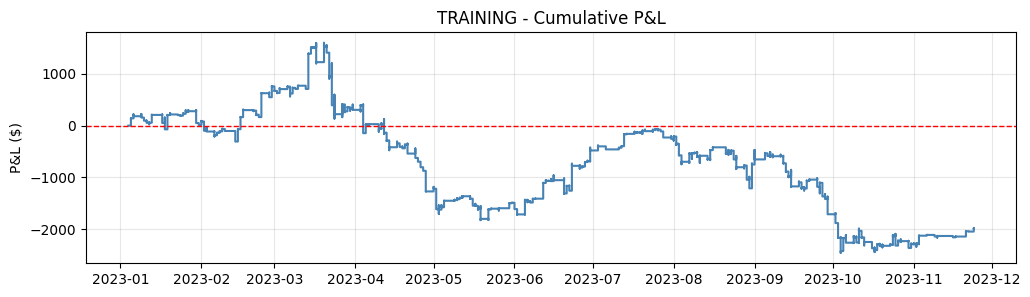

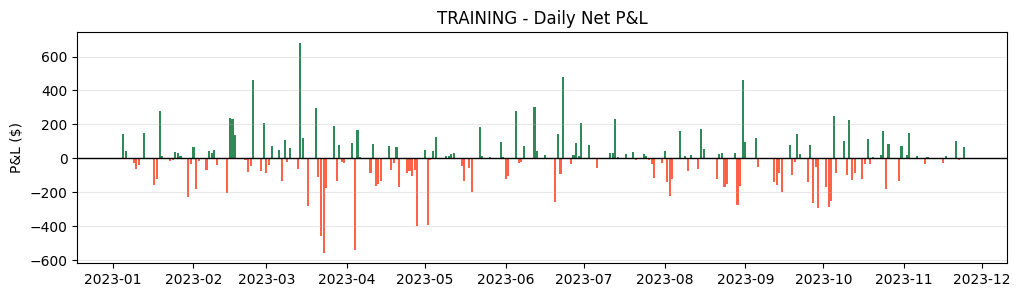

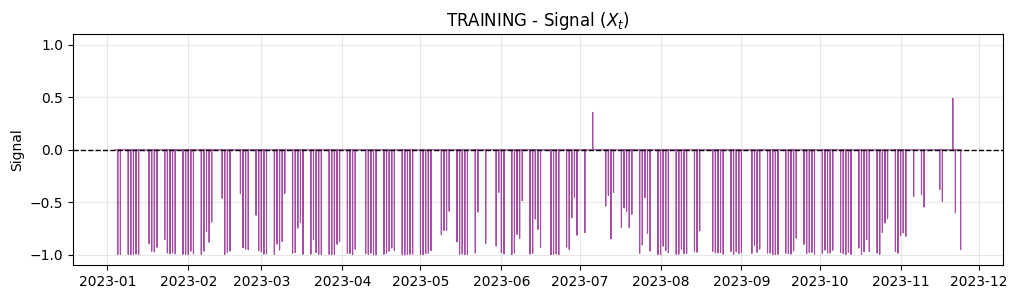

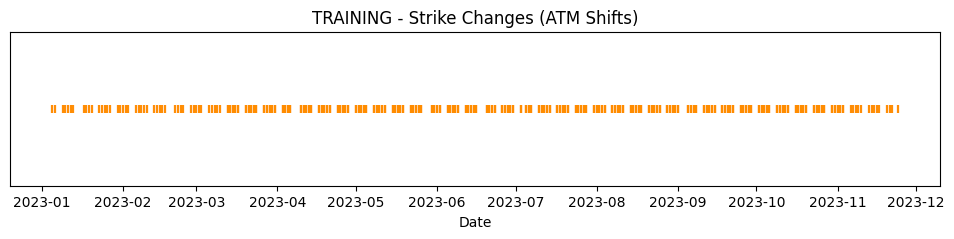

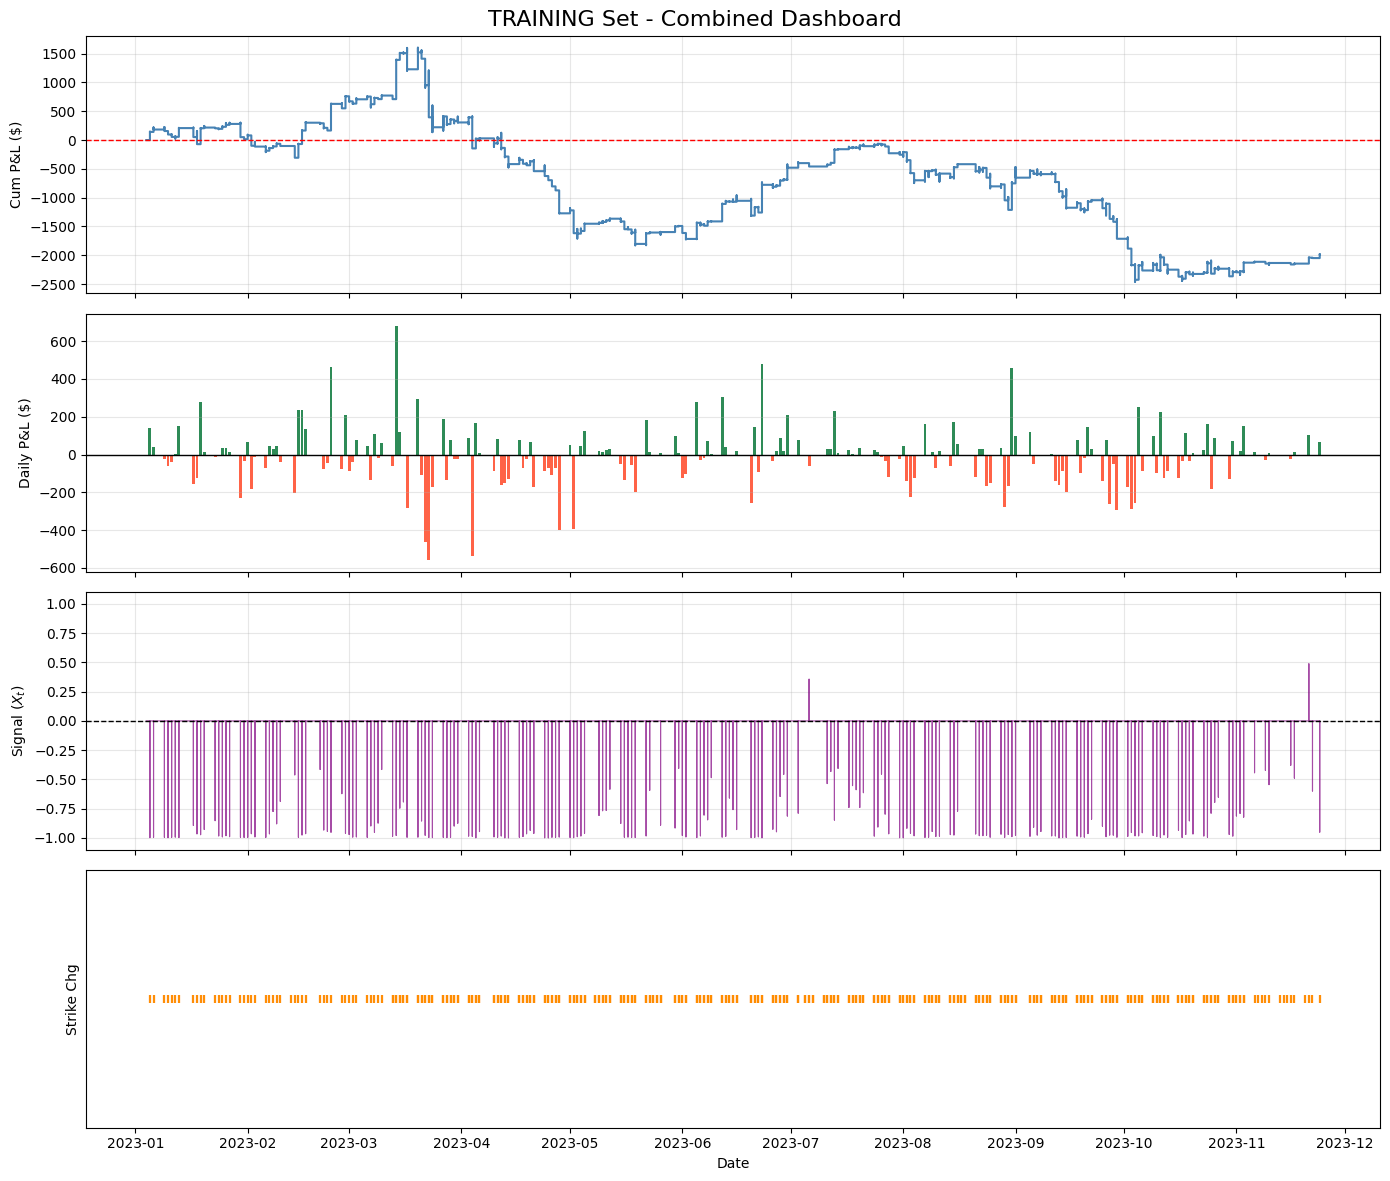


==================== VALIDATION SET PERFORMANCE ====================
Total Net P&L:         $81.17
Win Rate (Daily):      50.0%
Payoff Ratio (Bars):   1.240
Maximum Drawdown:      $568.05
Number of Trades:      68 (Bars with position change or strike roll)
Position Frequency:    Long: 0.0% | Short: 36.2% | Flat: 63.8%


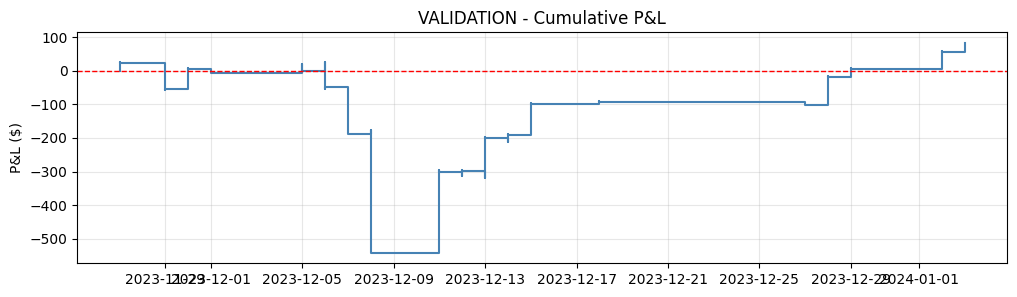

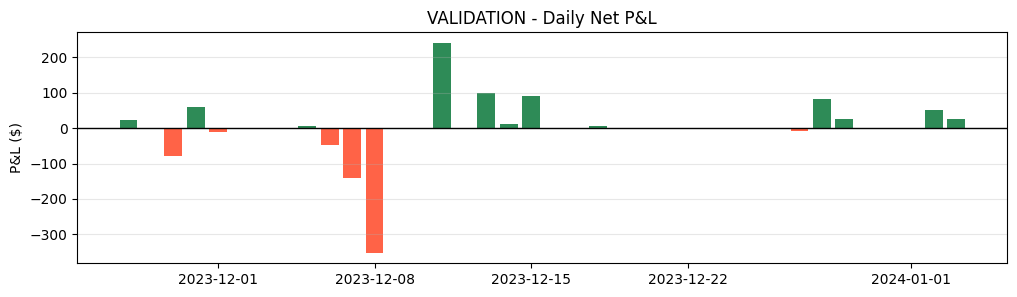

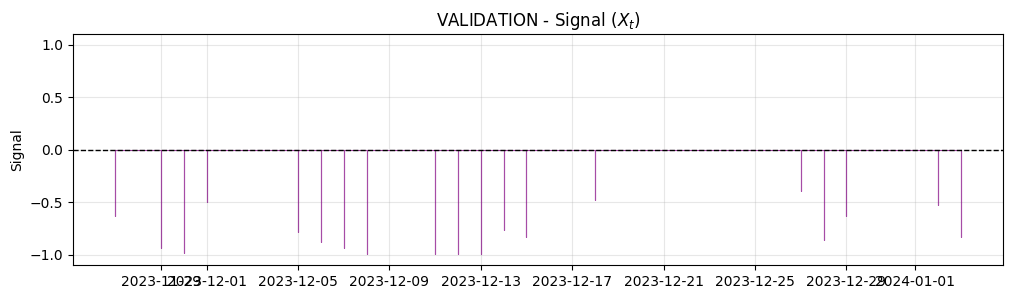

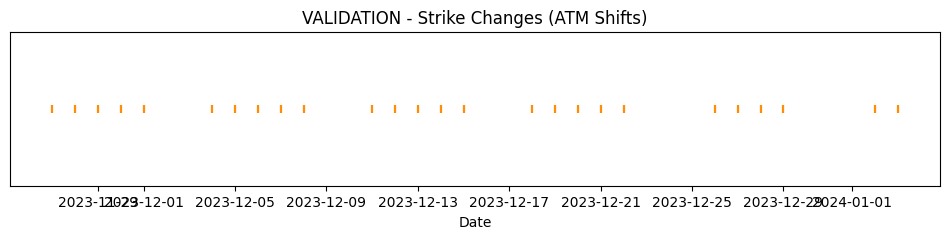

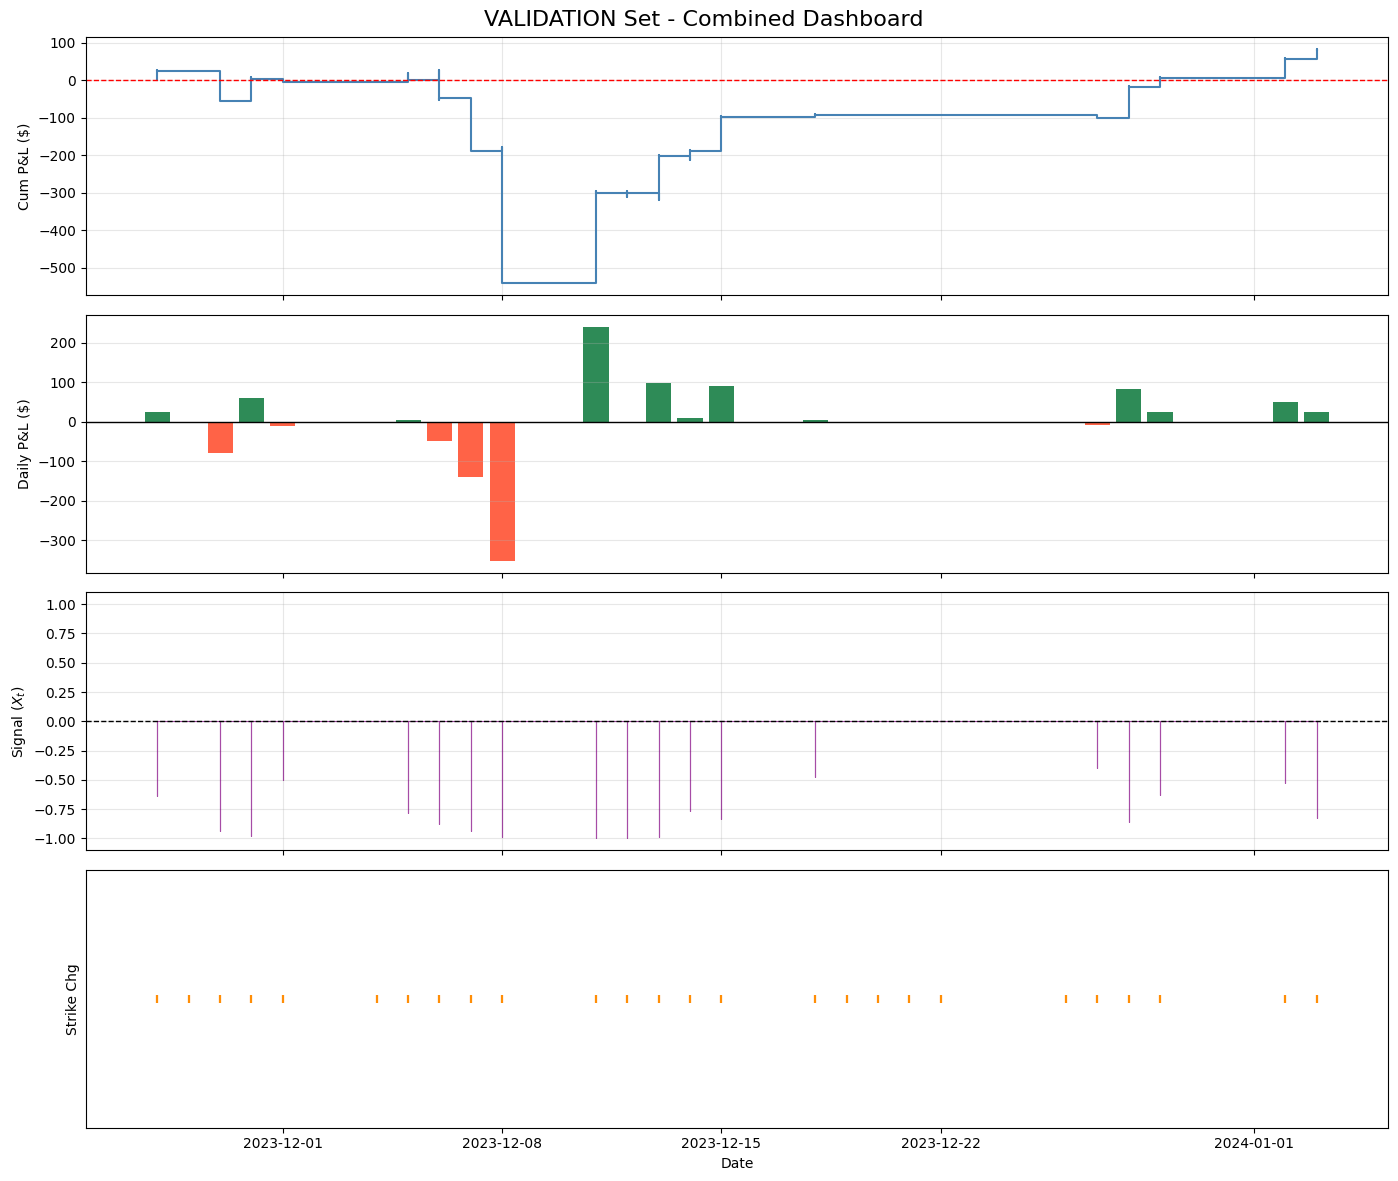


==================== TESTING SET PERFORMANCE ====================
Total Net P&L:         $97.44
Win Rate (Daily):      56.6%
Payoff Ratio (Bars):   1.060
Maximum Drawdown:      $944.02
Number of Trades:      694 (Bars with position change or strike roll)
Position Frequency:    Long: 0.0% | Short: 61.5% | Flat: 38.5%


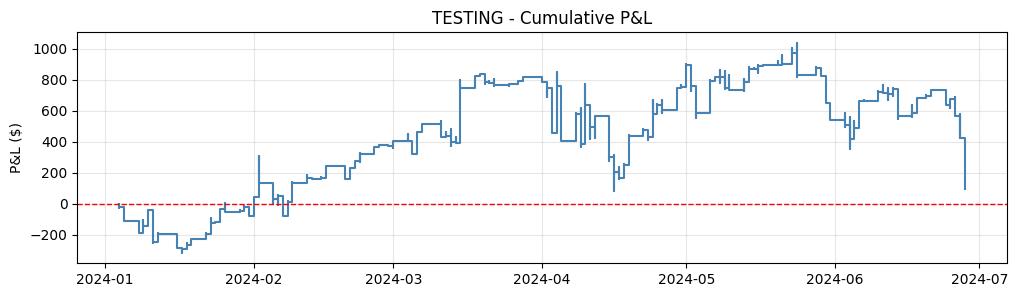

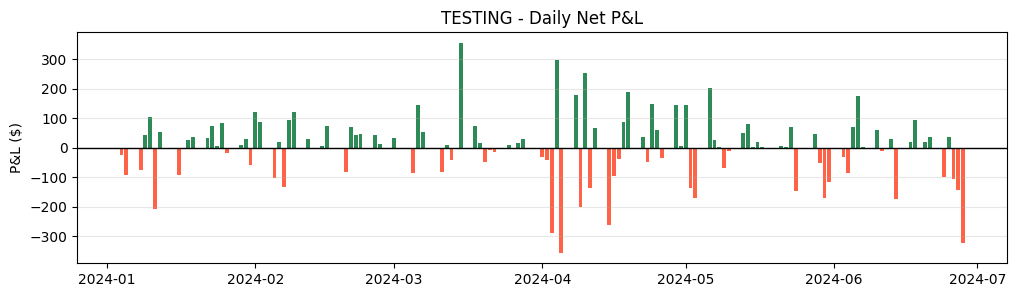

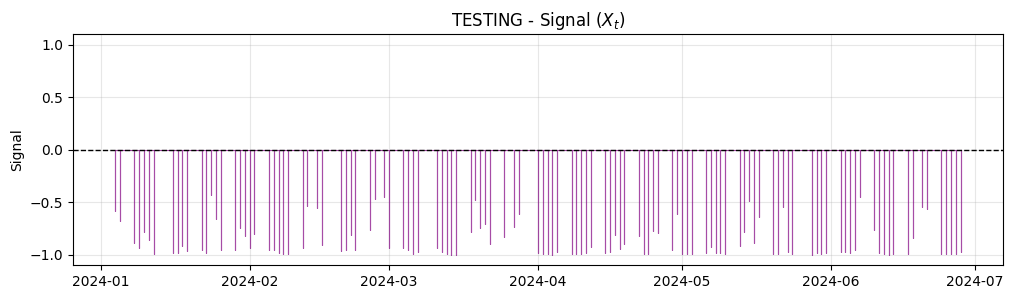

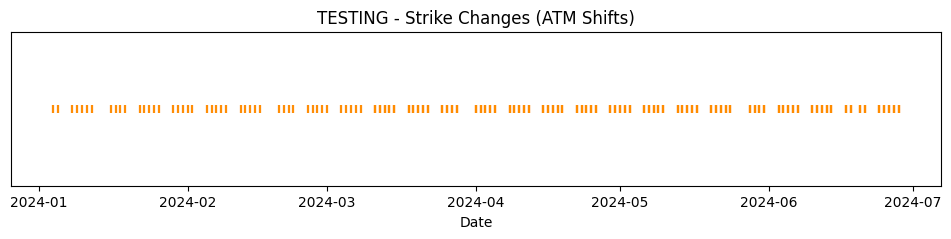

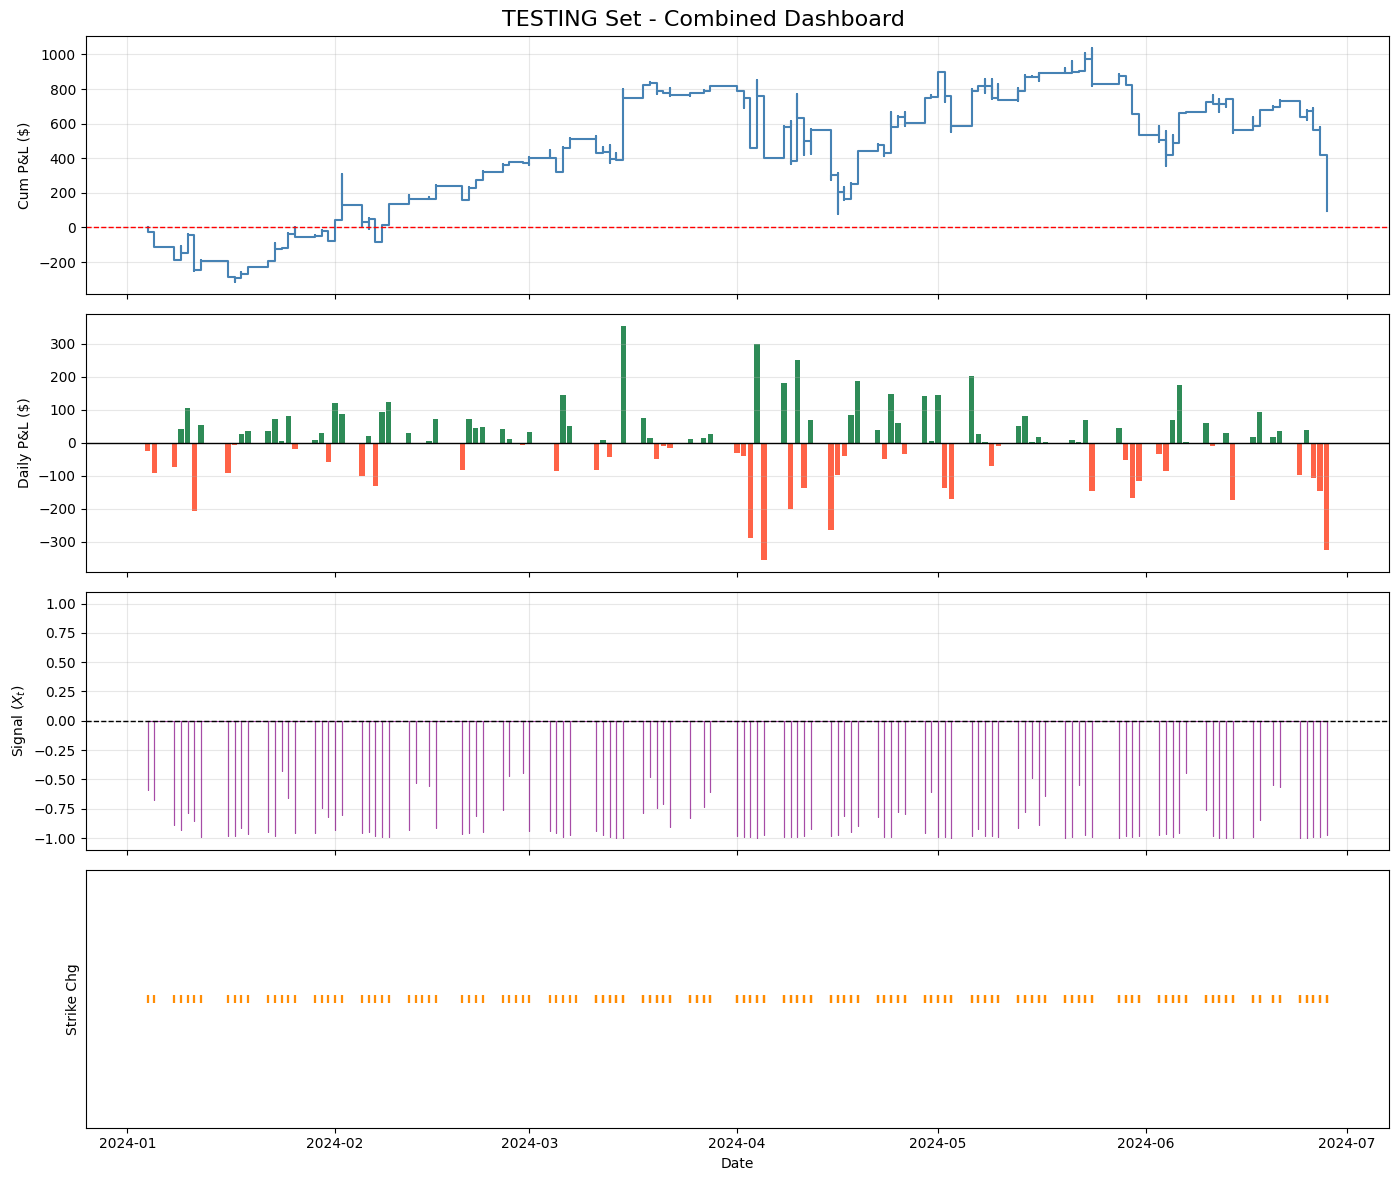

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

def analyze_and_plot_dataset(df_slice, name):
    # Create a copy and recalculate cum_pnl so it starts from $0 for this specific period
    df = df_slice.copy()
    df['cum_pnl'] = df['net_pnl'].cumsum()

    # Daily P&L
    daily_pnl = df.groupby("date")["net_pnl"].sum().reset_index()
    daily_pnl["date"] = pd.to_datetime(daily_pnl["date"])
    dates = pd.to_datetime(df["date"])

    # --- METRICS CALCULATION ---
    win_rate = (daily_pnl["net_pnl"] > 0).mean()

    winning_bars = df[df["net_pnl"] > 0]["net_pnl"]
    losing_bars = df[df["net_pnl"] < 0]["net_pnl"]
    avg_win = winning_bars.mean() if len(winning_bars) > 0 else 0
    avg_loss = losing_bars.mean() if len(losing_bars) > 0 else 0
    payoff_ratio = avg_win / abs(avg_loss) if avg_loss != 0 else float('inf')

    cum_max = df["cum_pnl"].cummax()
    max_dd = (cum_max - df["cum_pnl"]).max()

    num_trades = (df["tc_cost"] > 0).sum()
    n_bars = len(df)

    long_freq = (df["signal"] > 0).sum() / n_bars
    short_freq = (df["signal"] < 0).sum() / n_bars
    flat_freq = (df["signal"] == 0).sum() / n_bars

    # --- PRINT METRICS ---
    print(f"\n" + "="*20 + f" {name} SET PERFORMANCE " + "="*20)
    print(f"Total Net P&L:         ${df['cum_pnl'].iloc[-1]:.2f}")
    print(f"Win Rate (Daily):      {win_rate*100:.1f}%")
    print(f"Payoff Ratio (Bars):   {payoff_ratio:.3f}")
    print(f"Maximum Drawdown:      ${max_dd:.2f}")
    print(f"Number of Trades:      {num_trades} (Bars with position change or strike roll)")
    print(f"Position Frequency:    Long: {long_freq*100:.1f}% | Short: {short_freq*100:.1f}% | Flat: {flat_freq*100:.1f}%")

    # --- SEPARATE PLOTS ---
    # 1. Cumulative P&L
    plt.figure(figsize=(12, 3))
    plt.plot(dates, df["cum_pnl"], color="steelblue", lw=1.5)
    plt.axhline(0, color="red", ls="--", lw=1)
    plt.title(f"{name} - Cumulative P&L")
    plt.ylabel("P&L ($)")
    plt.grid(alpha=0.3)
    plt.show()

    # 2. Daily Net P&L
    plt.figure(figsize=(12, 3))
    plt.bar(daily_pnl["date"], daily_pnl["net_pnl"], color=np.where(daily_pnl["net_pnl"]>=0, "seagreen", "tomato"), width=0.8)
    plt.axhline(0, color="black", lw=1)
    plt.title(f"{name} - Daily Net P&L")
    plt.ylabel("P&L ($)")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    # 3. Signal Xt
    plt.figure(figsize=(12, 3))
    plt.plot(dates, df["signal"], color="purple", lw=0.8, alpha=0.7)
    plt.axhline(0, color="black", ls="--", lw=1)
    plt.ylim(-1.1, 1.1)
    plt.title(f"{name} - Signal ($X_t$)")
    plt.ylabel("Signal")
    plt.grid(alpha=0.3)
    plt.show()

    # 4. Strike Changes
    plt.figure(figsize=(12, 2))
    chg_dates = pd.to_datetime(df.loc[df["strike_changed"], "date"])
    plt.scatter(chg_dates, np.ones(len(chg_dates)), marker="|", color="darkorange", alpha=0.5)
    plt.yticks([])
    plt.title(f"{name} - Strike Changes (ATM Shifts)")
    plt.xlabel("Date")
    plt.show()

    # --- COMBINED PLOT ---
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f"{name} Set - Combined Dashboard", fontsize=16, y=0.98)

    axes[0].plot(dates, df["cum_pnl"], color="steelblue", lw=1.5)
    axes[0].axhline(0, color="red", ls="--", lw=1)
    axes[0].set_ylabel("Cum P&L ($)")
    axes[0].grid(alpha=0.3)

    axes[1].bar(daily_pnl["date"], daily_pnl["net_pnl"], color=np.where(daily_pnl["net_pnl"]>=0, "seagreen", "tomato"), width=0.8)
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_ylabel("Daily P&L ($)")
    axes[1].grid(axis="y", alpha=0.3)

    axes[2].plot(dates, df["signal"], color="purple", lw=0.8, alpha=0.7)
    axes[2].axhline(0, color="black", ls="--", lw=1)
    axes[2].set_ylim(-1.1, 1.1)
    axes[2].set_ylabel("Signal ($X_t$)")
    axes[2].grid(alpha=0.3)

    axes[3].scatter(chg_dates, np.ones(len(chg_dates)), marker="|", color="darkorange", alpha=0.5)
    axes[3].set_yticks([])
    axes[3].set_ylabel("Strike Chg")
    axes[3].set_xlabel("Date")

    plt.tight_layout()
    plt.show()

# Extract the slices based on the dates used during training
train_slice = pnl_df_final_imp[pnl_df_final_imp["date"].isin(train_dates)]
val_slice   = pnl_df_final_imp[pnl_df_final_imp["date"].isin(val_dates)]
test_slice  = pnl_df_final_imp[pnl_df_final_imp["date"].isin(test_dates)]

# Run the analysis for each
analyze_and_plot_dataset(train_slice, "TRAINING")
analyze_and_plot_dataset(val_slice, "VALIDATION")
analyze_and_plot_dataset(test_slice, "TESTING")
